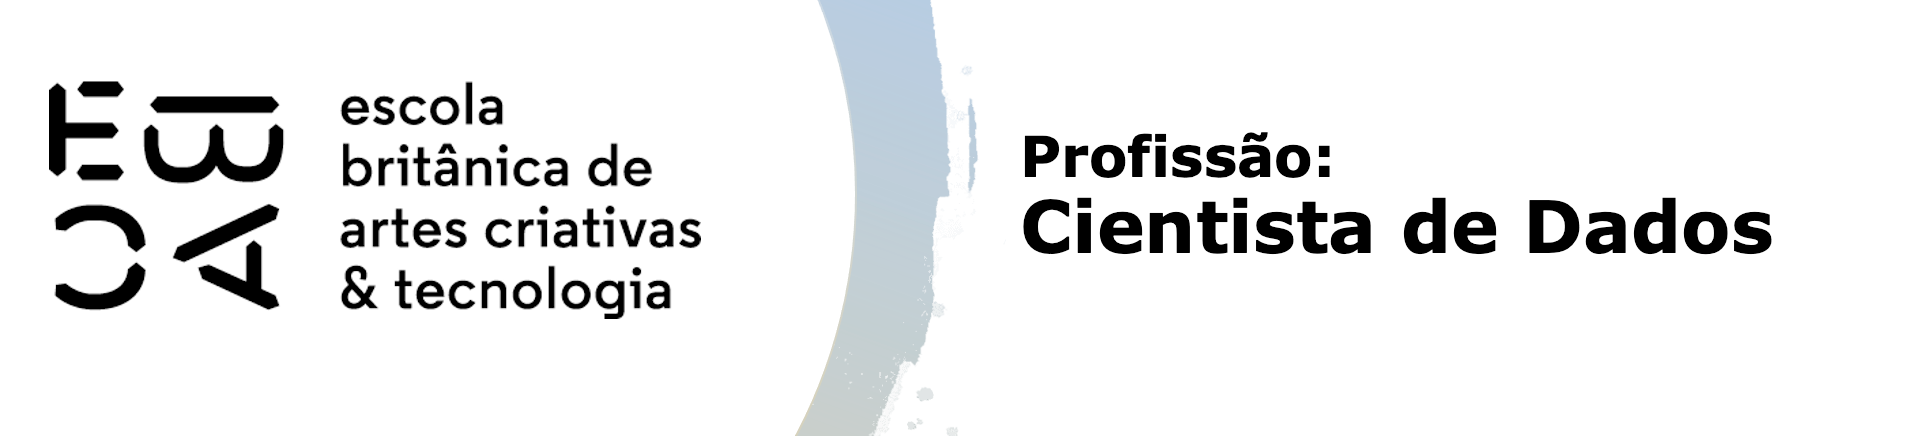

# Tarefa II

Neste projeto, estamos construindo um credit scoring para cartão de crédito, em um desenho amostral com 15 safras, e utilizando 12 meses de performance.

Carregue a base de dados ```credit_scoring.ftr```.

In [27]:
import pandas as pd

df = pd.read_feather('credit_scoring.ftr')
df.head()

,data_ref,index,sexo,posse_de_veiculo,posse_de_imovel,qtd_filhos,tipo_renda,educacao,estado_civil,tipo_residencia,idade,tempo_emprego,qt_pessoas_residencia,renda,mau
0,2015-01-01,5733,F,N,N,0,Empresário,Médio,Solteiro,Casa,43,6.873973,1.0,2515.39,False
1,2015-01-01,727,F,S,S,0,Assalariado,Médio,Casado,Casa,35,4.526027,2.0,3180.19,False
2,2015-01-01,6374,F,N,N,2,Assalariado,Médio,Casado,Casa,31,0.243836,4.0,1582.29,False
3,2015-01-01,9566,F,N,N,0,Assalariado,Médio,Casado,Casa,54,12.772603,2.0,13721.17,False
4,2015-01-01,9502,F,S,N,0,Assalariado,Superior incompleto,Solteiro,Casa,31,8.432877,1.0,2891.08,False


In [28]:
import subprocess, sys

pacotes = ['scikit-learn', 'scipy', 'matplotlib']
for p in pacotes:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', p, '-q'])

## Amostragem

Separe os três últimos meses como safras de validação *out of time* (oot).

Variáveis:<br>
Considere que a variável ```data_ref``` não é uma variável explicativa, é somente uma variável indicadora da safra, e não deve ser utilizada na modelagem. A variávei ```index``` é um identificador do cliente, e também não deve ser utilizada como covariável (variável explicativa). As restantes podem ser utilizadas para prever a inadimplência, incluindo a renda.


In [29]:

# Verificando as safras disponíveis
print(f"Shape da base: {df.shape}")
print(f"\nSafras disponíveis ({df['data_ref'].nunique()} meses):")
print(df.groupby('data_ref').size().rename('qtd').to_string())

# Separando os últimos 3 meses como OOT
datas = sorted(df['data_ref'].unique())
datas_oot = datas[-3:]
datas_dev = datas[:-3]

print(f"\nSafras de desenvolvimento ({len(datas_dev)} meses):")
print([str(d)[:10] for d in datas_dev])
print(f"\nSafras OOT ({len(datas_oot)} meses):")
print([str(d)[:10] for d in datas_oot])

df_dev = df[df['data_ref'].isin(datas_dev)].copy()
df_oot = df[df['data_ref'].isin(datas_oot)].copy()

# Definindo features (excluindo data_ref e index)
features = [c for c in df.columns if c not in ['data_ref', 'index', 'mau']]

X_dev = df_dev[features].copy()
y_dev = df_dev['mau'].astype(int)
X_oot = df_oot[features].copy()
y_oot = df_oot['mau'].astype(int)

print(f"\nBase de desenvolvimento: {df_dev.shape[0]:,} registros")
print(f"Base OOT:               {df_oot.shape[0]:,} registros")
print(f"\nTaxa de inadimplência (dev): {y_dev.mean():.2%}")
print(f"Taxa de inadimplência (oot): {y_oot.mean():.2%}")


Shape da base: (750000, 15)

Safras disponíveis (15 meses):
data_ref
2015-01-01    50000
2015-02-01    50000
2015-03-01    50000
2015-04-01    50000
2015-05-01    50000
2015-06-01    50000
2015-07-01    50000
2015-08-01    50000
2015-09-01    50000
2015-10-01    50000
2015-11-01    50000
2015-12-01    50000
2016-01-01    50000
2016-02-01    50000
2016-03-01    50000

Safras de desenvolvimento (12 meses):
['2015-01-01', '2015-02-01', '2015-03-01', '2015-04-01', '2015-05-01', '2015-06-01', '2015-07-01', '2015-08-01', '2015-09-01', '2015-10-01', '2015-11-01', '2015-12-01']

Safras OOT (3 meses):
['2016-01-01', '2016-02-01', '2016-03-01']

Base de desenvolvimento: 600,000 registros
Base OOT:               150,000 registros

Taxa de inadimplência (dev): 6.11%
Taxa de inadimplência (oot): 14.67%


## Descritiva básica univariada

- Descreva a base quanto ao número de linhas, número de linhas para cada mês em ```data_ref```.
- Faça uma descritiva básica univariada de cada variável. Considere as naturezas diferentes: qualitativas e quantitativas.

=== DIMENSÕES DA BASE ===
Total de linhas:  750,000
Total de colunas: 15

=== VALORES NULOS POR COLUNA ===
tempo_emprego    125957
Total de nulos: 125957

=== REGISTROS POR SAFRA ===
data_ref
2015-01-01    50000
2015-02-01    50000
2015-03-01    50000
2015-04-01    50000
2015-05-01    50000
2015-06-01    50000
2015-07-01    50000
2015-08-01    50000
2015-09-01    50000
2015-10-01    50000
2015-11-01    50000
2015-12-01    50000
2016-01-01    50000
2016-02-01    50000
2016-03-01    50000

=== VARIÁVEIS QUALITATIVAS ===

sexo:
sexo
F    67.28
M    32.72

posse_de_veiculo:
posse_de_veiculo
N    61.06
S    38.94

posse_de_imovel:
posse_de_imovel
S    67.16
N    32.84

tipo_renda:
tipo_renda
Assalariado         51.43
Empresário          23.03
Pensionista         16.84
Servidor público     8.66
Bolsista             0.05

educacao:
educacao
Médio                  67.58
Superior completo      27.24
Superior incompleto     3.93
Fundamental             1.14
Pós graduação           0.11

estado_c

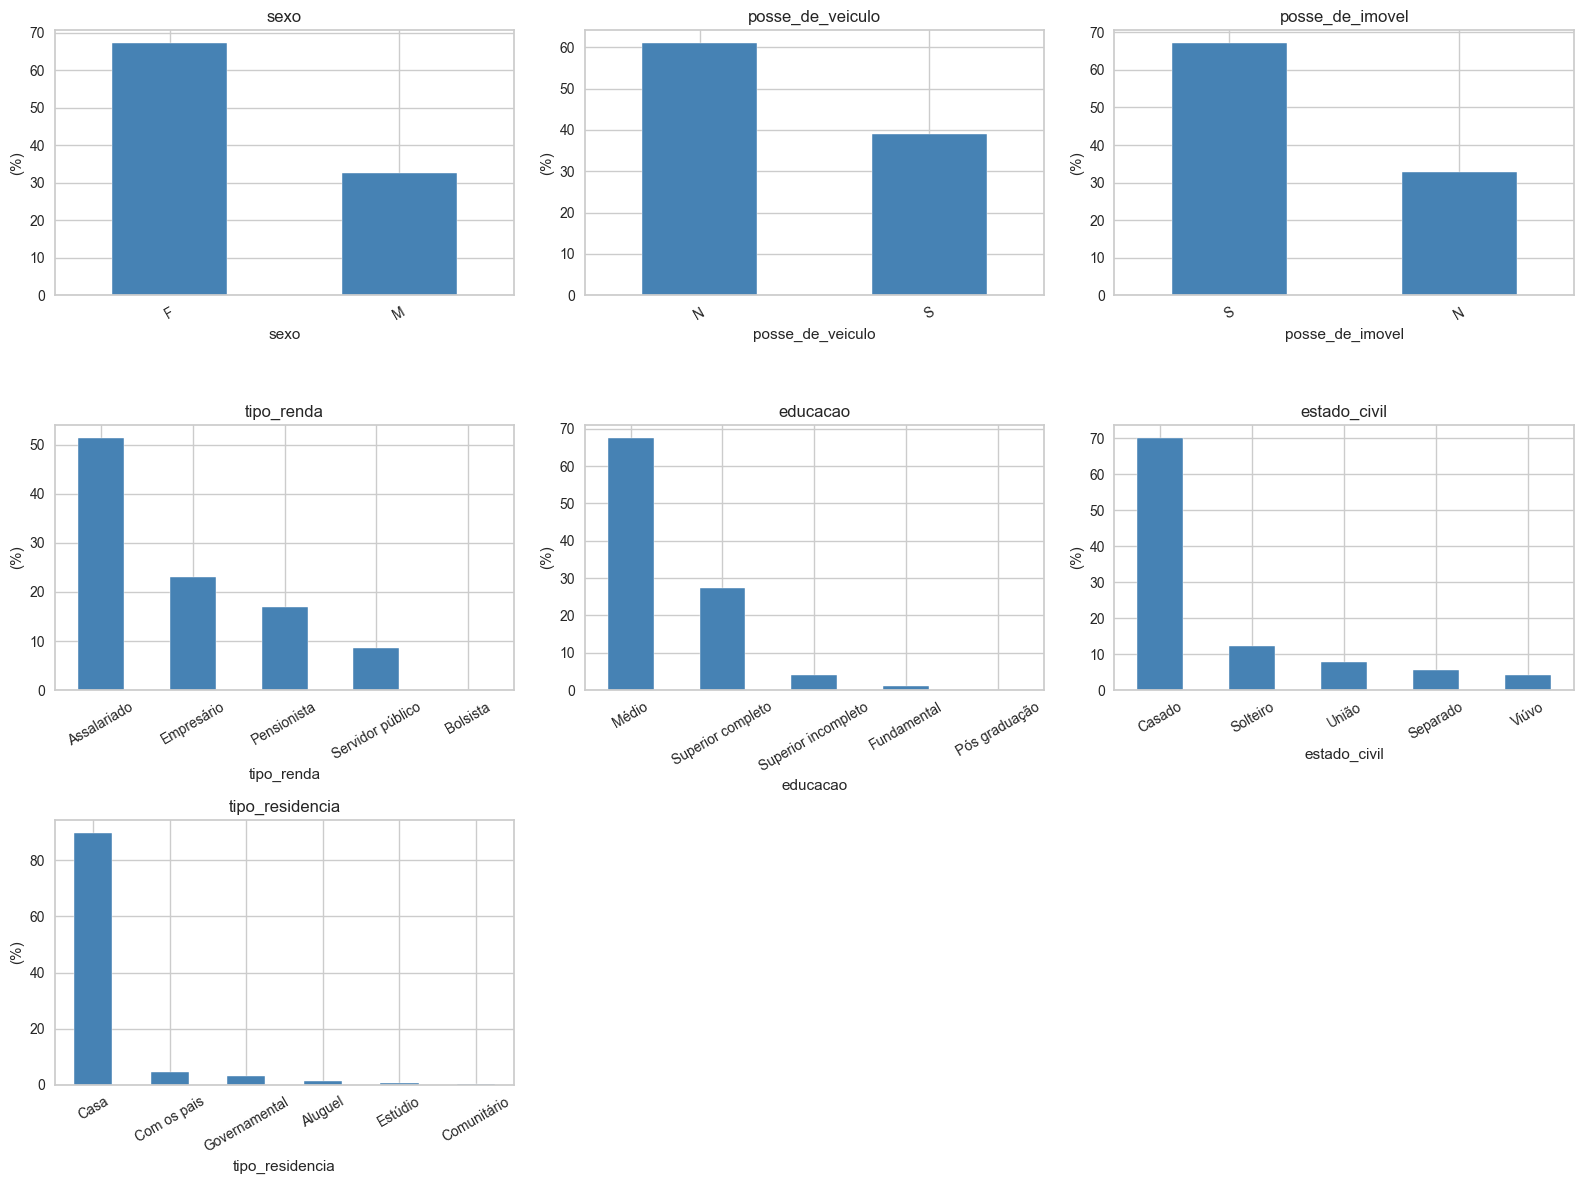


=== VARIÁVEIS QUANTITATIVAS ===


,qtd_filhos,idade,tempo_emprego,qt_pessoas_residencia,renda
count,750000.00,750000.00,624043.00,750000.00,750000.00
mean,0.43,43.80,7.75,2.21,23238.54
std,0.74,11.23,6.69,0.90,79106.01
min,0.00,22.00,0.12,1.00,107.67
25%,0.00,34.00,3.05,2.00,3467.70
50%,0.00,43.00,6.05,2.00,7861.82
75%,1.00,53.00,10.18,3.00,18318.28
max,14.00,68.00,42.91,15.00,4083986.22


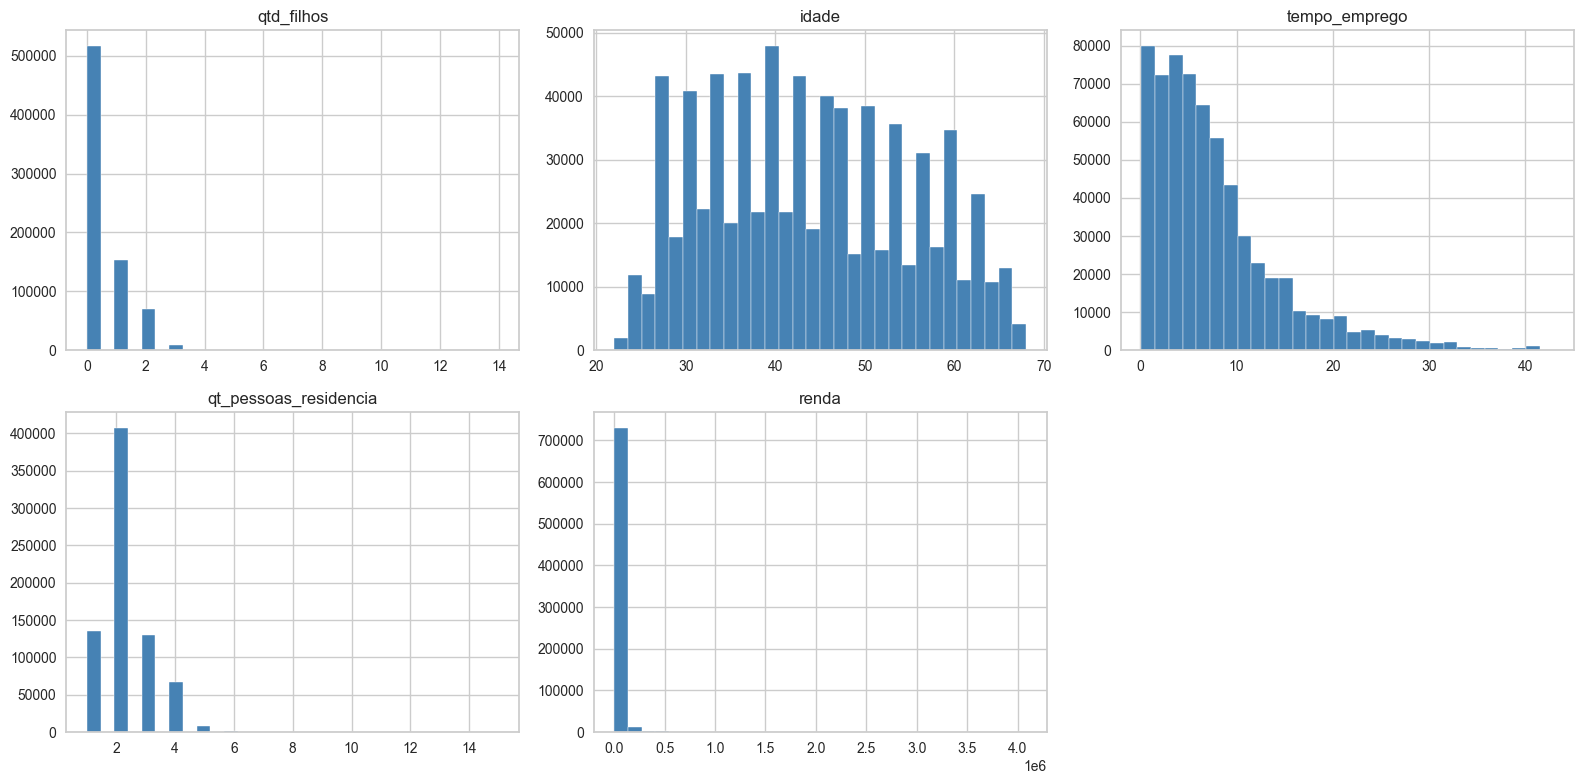

In [30]:
import matplotlib.pyplot as plt

cat_cols = ['sexo', 'posse_de_veiculo', 'posse_de_imovel',
            'tipo_renda', 'educacao', 'estado_civil', 'tipo_residencia']
num_cols = ['qtd_filhos', 'idade', 'tempo_emprego', 'qt_pessoas_residencia', 'renda']

# --- Dimensões e nulos ---
print("=== DIMENSÕES DA BASE ===")
print(f"Total de linhas:  {df.shape[0]:,}")
print(f"Total de colunas: {df.shape[1]}")

print("\n=== VALORES NULOS POR COLUNA ===")
nulos = df.isnull().sum()
print(nulos[nulos > 0].to_string() if nulos.sum() > 0 else "Nenhum nulo encontrado")
print(f"Total de nulos: {nulos.sum()}")

# --- Registros por safra ---
print("\n=== REGISTROS POR SAFRA ===")
print(df.groupby('data_ref').size().rename('qtd').to_string())

# --- Variáveis categóricas ---
print("\n=== VARIÁVEIS QUALITATIVAS ===")
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()
for i, col in enumerate(cat_cols):
    freq = df[col].value_counts(normalize=True).mul(100).round(2)
    print(f"\n{col}:\n{freq.to_string()}")
    freq.plot(kind='bar', ax=axes[i], color='steelblue', edgecolor='white')
    axes[i].set_title(col, fontsize=12)
    axes[i].set_ylabel('(%)')
    axes[i].tick_params(axis='x', rotation=30)
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)
plt.tight_layout()
plt.show()

# --- Variáveis numéricas ---
print("\n=== VARIÁVEIS QUANTITATIVAS ===")
display(df[num_cols].describe().round(2))

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    df[col].hist(ax=axes[i], bins=30, color='steelblue', edgecolor='white')
    axes[i].set_title(col, fontsize=12)
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)
plt.tight_layout()
plt.show()

## Descritiva bivariada

Faça uma análise descritiva bivariada de cada variável

=== TAXA DE MAU POR VARIÁVEL CATEGÓRICA ===

sexo:
sexo
F    8.05
M    7.34

posse_de_veiculo:
posse_de_veiculo
N    7.88
S    7.73

posse_de_imovel:
posse_de_imovel
N    8.85
S    7.32

tipo_renda:
tipo_renda
Pensionista         8.27
Assalariado         8.09
Empresário          7.65
Servidor público    5.81
Bolsista            4.16

educacao:
educacao
Fundamental            9.17
Superior incompleto    8.30
Médio                  8.04
Pós graduação          7.27
Superior completo      7.16

estado_civil:
estado_civil
União       8.39
Separado    8.18
Solteiro    8.12
Casado      7.70
Viúvo       7.46

tipo_residencia:
tipo_residencia
Com os pais      9.47
Aluguel          9.02
Comunitário      8.45
Governamental    8.22
Casa             7.71
Estúdio          6.54


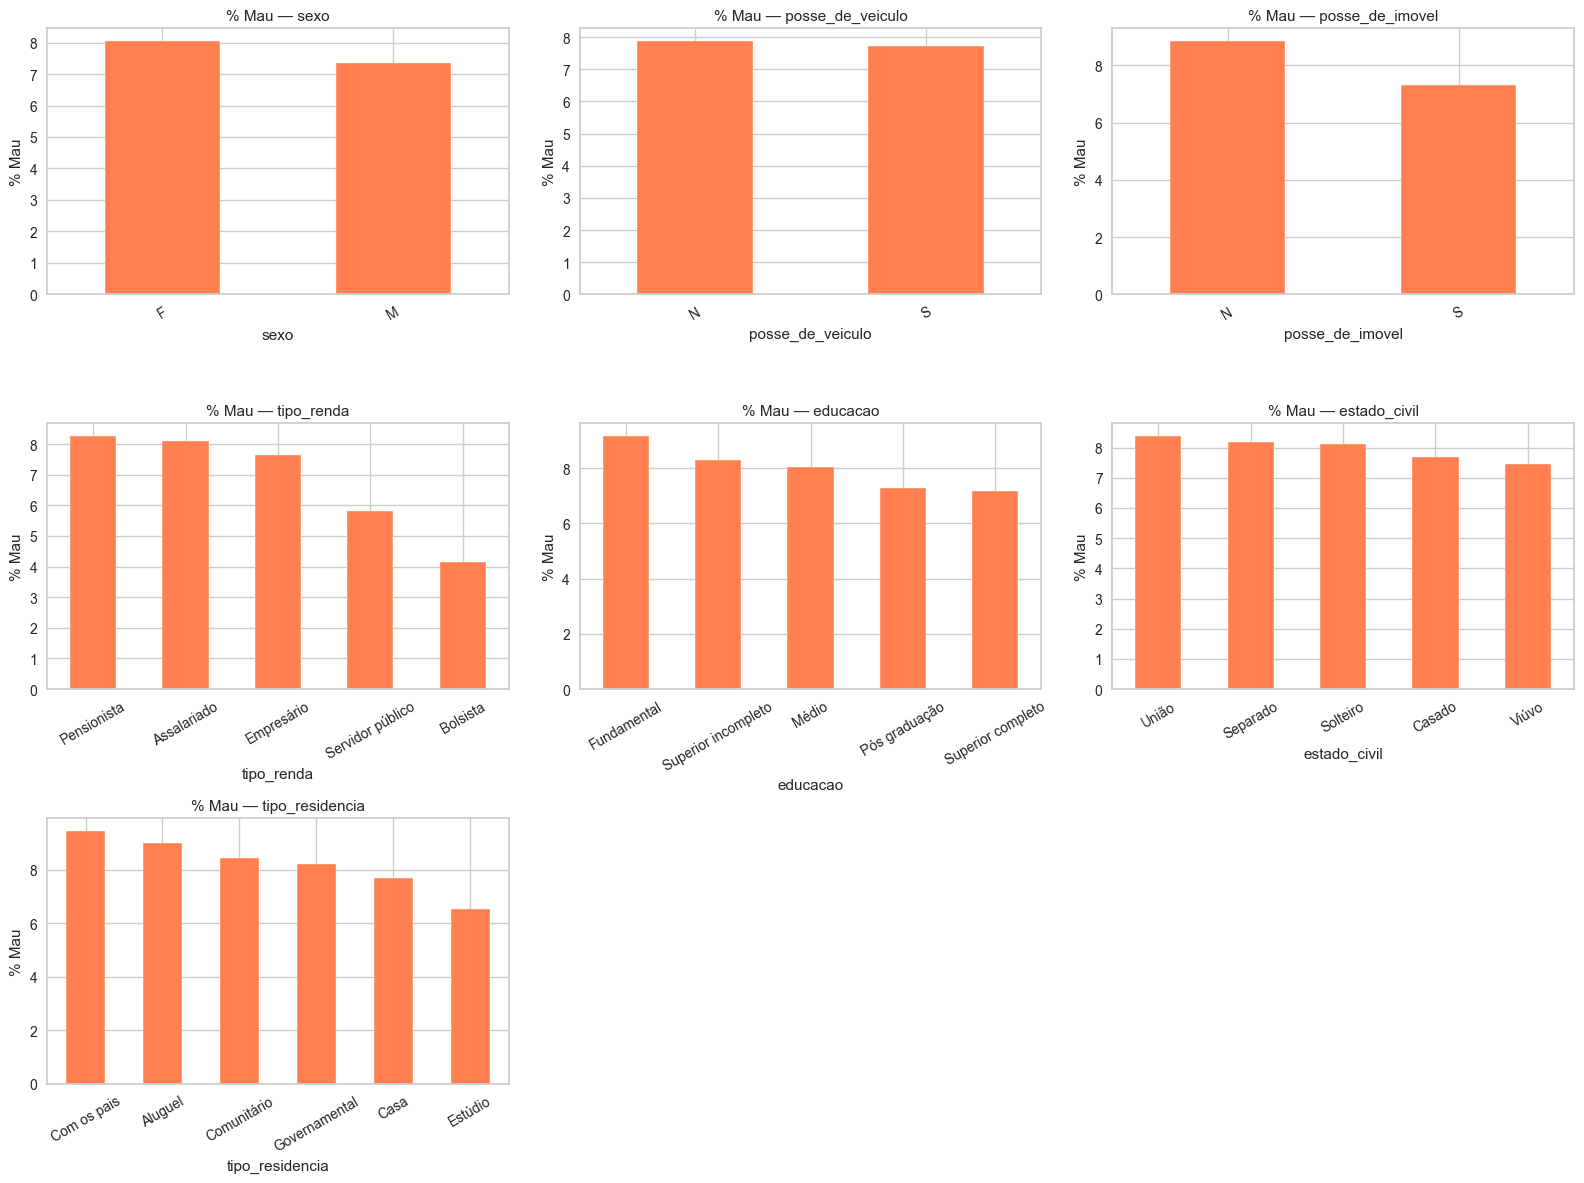


=== DISTRIBUIÇÃO DAS VARIÁVEIS NUMÉRICAS POR MAU ===


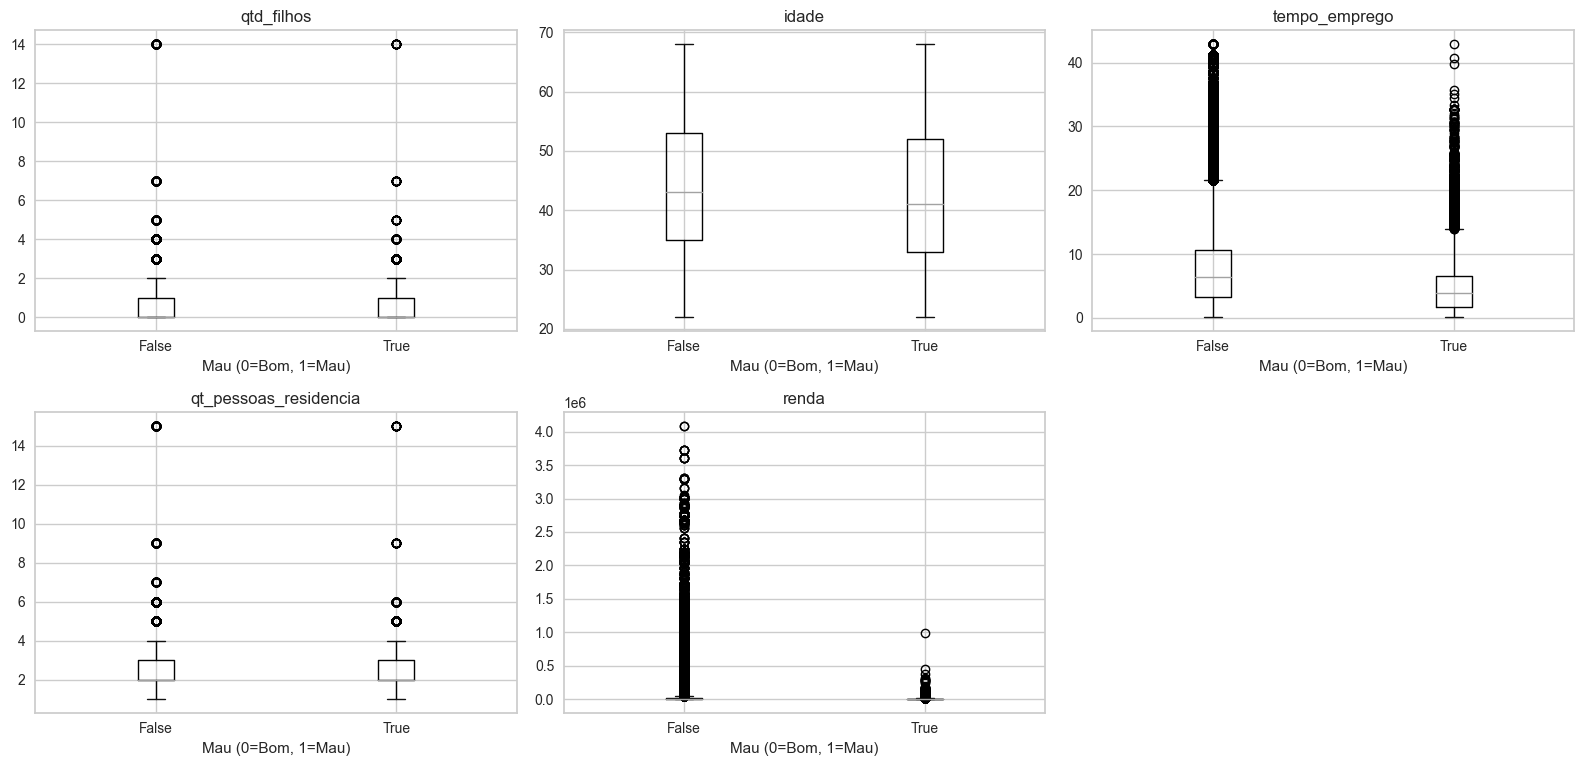


Média das variáveis numéricas por mau:


,qtd_filhos,idade,tempo_emprego,qt_pessoas_residencia,renda
mau,,,,,
False,0.43,43.90,8.0,2.21,24804.69
True,0.45,42.73,4.7,2.22,4774.87


In [31]:

# --- Taxa de inadimplência por variável categórica ---
print("=== TAXA DE MAU POR VARIÁVEL CATEGÓRICA ===")
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()
for i, col in enumerate(cat_cols):
    taxa = df.groupby(col)['mau'].mean().mul(100).sort_values(ascending=False).round(2)
    print(f"\n{col}:\n{taxa.to_string()}")
    taxa.plot(kind='bar', ax=axes[i], color='coral', edgecolor='white')
    axes[i].set_title(f'% Mau — {col}', fontsize=11)
    axes[i].set_ylabel('% Mau')
    axes[i].tick_params(axis='x', rotation=30)
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)
plt.tight_layout()
plt.show()

# --- Distribuição das numéricas por mau (boxplot) ---
print("\n=== DISTRIBUIÇÃO DAS VARIÁVEIS NUMÉRICAS POR MAU ===")
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    df.boxplot(column=col, by='mau', ax=axes[i])
    axes[i].set_title(col, fontsize=12)
    axes[i].set_xlabel('Mau (0=Bom, 1=Mau)')
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)
plt.suptitle('')
plt.tight_layout()
plt.show()

# Comparação das médias
print("\nMédia das variáveis numéricas por mau:")
display(df.groupby('mau')[num_cols].mean().round(2))


## Desenvolvimento do modelo

Desenvolva um modelo de *credit scoring* através de uma regressão logística.

- Trate valores missings e outliers
- Trate 'zeros estruturais'
- Faça agrupamentos de categorias conforme vimos em aula
- Proponha uma equação preditiva para 'mau'
- Caso hajam categorias não significantes, justifique

In [32]:
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

# ---- 1. Cópia das bases ----
X_tr = X_dev.copy()
X_ts = X_oot.copy()

num_cols_m = ['qtd_filhos', 'idade', 'tempo_emprego', 'qt_pessoas_residencia', 'renda']
cat_cols_m = ['sexo', 'posse_de_veiculo', 'posse_de_imovel',
              'tipo_renda', 'educacao', 'estado_civil', 'tipo_residencia']

# ---- 2. Zeros estruturais: tempo_emprego nulo = desempregado ----
X_tr['flag_sem_emprego'] = X_tr['tempo_emprego'].isna().astype(int)
X_ts['flag_sem_emprego'] = X_ts['tempo_emprego'].isna().astype(int)

# ---- 3. Imputação de nulos ----
imp_num = SimpleImputer(strategy='median')
X_tr[num_cols_m] = imp_num.fit_transform(X_tr[num_cols_m])
X_ts[num_cols_m] = imp_num.transform(X_ts[num_cols_m])

imp_cat = SimpleImputer(strategy='most_frequent')
X_tr[cat_cols_m] = imp_cat.fit_transform(X_tr[cat_cols_m])
X_ts[cat_cols_m] = imp_cat.transform(X_ts[cat_cols_m])

# ---- 4. Winsorização de outliers (p1 / p99) ----
for col in num_cols_m:
    p1  = X_tr[col].quantile(0.01)
    p99 = X_tr[col].quantile(0.99)
    X_tr[col] = X_tr[col].clip(p1, p99)
    X_ts[col] = X_ts[col].clip(p1, p99)

# ---- 5. Agrupamento de categorias ----
edu_map = {
    'Secundário': 'Secundário', 'Médio': 'Médio',
    'Superior incompleto': 'Superior', 'Superior completo': 'Superior',
    'Pós graduação': 'Superior', 'Acadêmico': 'Superior',
}
res_comuns = ['Casa', 'Com os pais', 'Aluguel']
for df_ in [X_tr, X_ts]:
    df_['educacao'] = df_['educacao'].map(edu_map).fillna('Outros')
    df_['tipo_residencia'] = df_['tipo_residencia'].apply(
        lambda x: x if x in res_comuns else 'Outros')

# ---- 6. Criação de dummies ----
X_tr_enc = pd.get_dummies(X_tr, columns=cat_cols_m, drop_first=True)
X_ts_enc = pd.get_dummies(X_ts, columns=cat_cols_m, drop_first=True)
X_tr_enc, X_ts_enc = X_tr_enc.align(X_ts_enc, join='left', axis=1, fill_value=0)
X_tr_enc = X_tr_enc.astype(float)
X_ts_enc = X_ts_enc.astype(float)

# ---- 7. Escalonamento ----
scaler_m = StandardScaler()
X_tr_sc = scaler_m.fit_transform(X_tr_enc)
X_ts_sc = scaler_m.transform(X_ts_enc)

# ---- 8. Regressão Logística ----
model_lr = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
model_lr.fit(X_tr_sc, y_dev)

print("Modelo de Regressão Logística treinado!")
print(f"Número de features: {X_tr_sc.shape[1]}")

coef_df = pd.DataFrame({
    'feature': X_tr_enc.columns,
    'coef': model_lr.coef_[0],
    'odds_ratio': np.exp(model_lr.coef_[0])
}).sort_values('coef', key=abs, ascending=False)

print("\nTop 15 features por importância (|coef|):")
display(coef_df.head(15))

Modelo de Regressão Logística treinado!
Número de features: 22

Top 15 features por importância (|coef|):


,feature,coef,odds_ratio
4,renda,-3.552292,0.028659
2,tempo_emprego,-0.148112,0.862334
6,sexo_M,-0.064063,0.937946
8,posse_de_imovel_S,-0.044958,0.956038
14,educacao_Superior,-0.030439,0.970020
10,tipo_renda_Empresário,-0.023654,0.976623
5,flag_sem_emprego,-0.021577,0.978654
19,tipo_residencia_Casa,-0.019369,0.980817
7,posse_de_veiculo_S,0.017786,1.017945
21,tipo_residencia_Outros,-0.015891,0.984234


## Avaliação do modelo

Avalie o poder discriminante do modelo pelo menos avaliando acurácia, KS e Gini.

Avalie estas métricas nas bases de desenvolvimento e *out of time*.


  BASE DE DESENVOLVIMENTO
  Acurácia : 0.5511
  AUC-ROC  : 0.7623
  KS       : 0.3910
  Gini     : 0.5246

              precision    recall  f1-score   support

         Bom       0.98      0.53      0.69    563357
         Mau       0.10      0.83      0.18     36643

    accuracy                           0.55    600000
   macro avg       0.54      0.68      0.44    600000
weighted avg       0.93      0.55      0.66    600000


  BASE OUT OF TIME (OOT)
  Acurácia : 0.3079
  AUC-ROC  : 0.7138
  KS       : 0.3149
  Gini     : 0.4277

              precision    recall  f1-score   support

         Bom       0.97      0.19      0.32    128000
         Mau       0.17      0.97      0.29     22000

    accuracy                           0.31    150000
   macro avg       0.57      0.58      0.31    150000
weighted avg       0.86      0.31      0.32    150000



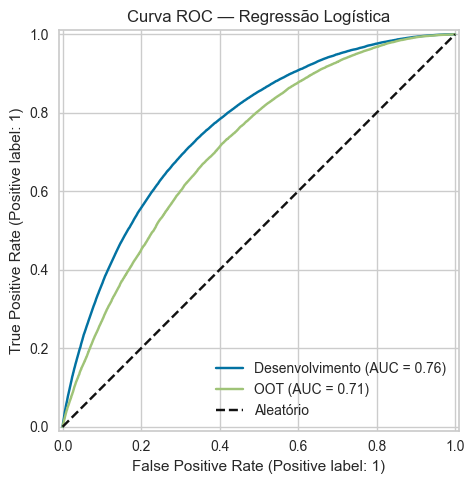

In [33]:
from sklearn.metrics import (accuracy_score, roc_auc_score,
                              classification_report, RocCurveDisplay)
from scipy.stats import ks_2samp

def ks_statistic(y_true, y_score):
    pos = y_score[np.array(y_true) == 1]
    neg = y_score[np.array(y_true) == 0]
    return ks_2samp(pos, neg)[0]

def gini(y_true, y_score):
    return 2 * roc_auc_score(y_true, y_score) - 1

def avaliar(nome, y_true, y_score, threshold=0.5):
    y_pred = (y_score >= threshold).astype(int)
    print(f"\n{'='*45}")
    print(f"  {nome}")
    print(f"{'='*45}")
    print(f"  Acurácia : {accuracy_score(y_true, y_pred):.4f}")
    print(f"  AUC-ROC  : {roc_auc_score(y_true, y_score):.4f}")
    print(f"  KS       : {ks_statistic(y_true, y_score):.4f}")
    print(f"  Gini     : {gini(y_true, y_score):.4f}")
    print()
    print(classification_report(y_true, y_pred, target_names=['Bom', 'Mau']))

prob_dev_lr = model_lr.predict_proba(X_tr_sc)[:, 1]
prob_oot_lr = model_lr.predict_proba(X_ts_sc)[:, 1]

avaliar("BASE DE DESENVOLVIMENTO", y_dev.values, prob_dev_lr)
avaliar("BASE OUT OF TIME (OOT)", y_oot.values, prob_oot_lr)

fig, ax = plt.subplots(figsize=(7, 5))
RocCurveDisplay.from_predictions(y_dev, prob_dev_lr, ax=ax, name='Desenvolvimento')
RocCurveDisplay.from_predictions(y_oot, prob_oot_lr, ax=ax, name='OOT')
ax.plot([0, 1], [0, 1], 'k--', label='Aleatório')
ax.set_title('Curva ROC — Regressão Logística')
ax.legend()
plt.tight_layout()
plt.show()

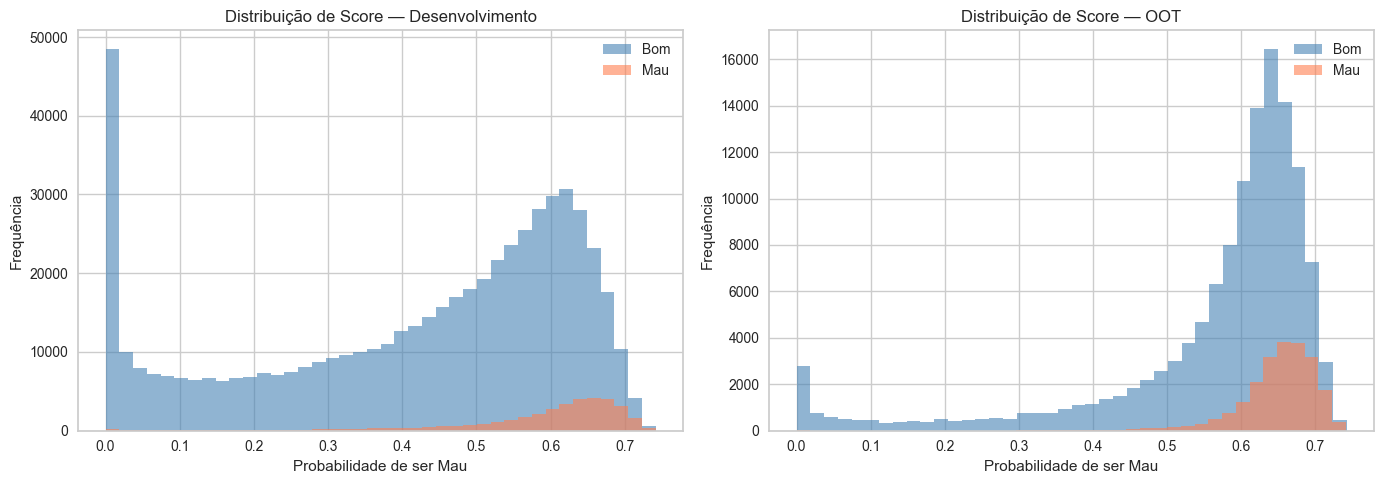

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (nome, y_true, prob) in zip(axes, [
    ("Desenvolvimento", y_dev.values, prob_dev_lr),
    ("OOT",            y_oot.values, prob_oot_lr),
]):
    ax.hist(prob[y_true == 0], bins=40, alpha=0.6, color='steelblue', label='Bom')
    ax.hist(prob[y_true == 1], bins=40, alpha=0.6, color='coral',     label='Mau')
    ax.set_title(f'Distribuição de Score — {nome}')
    ax.set_xlabel('Probabilidade de ser Mau')
    ax.set_ylabel('Frequência')
    ax.legend()
plt.tight_layout()
plt.show()

## Criar um pipeline utilizando o sklearn pipeline 

In [35]:
# Esta seção apresenta o pipeline completo de pré-processamento usando sklearn.
# As etapas estão detalhadas nas subseções abaixo:
# 1. Substituição de nulos (ImputadorMisto)
# 2. Remoção de outliers (WinsorizadorOutliers)
# 3. Criação de dummies (CriadorDummies)
# 4. Escalonamento (StandardScaler)
# 5. Redução de dimensionalidade (AplicadorPCA)
print('Pipeline sklearn — estrutura definida nas células seguintes.')

Pipeline sklearn — estrutura definida nas células seguintes.


## Pré processamento

### Substituição de nulos (nans)

Existe nulos na base? é dado numérico ou categórico? qual o valor de substituição? média? valor mais frequente? etc

In [36]:
from sklearn.base import BaseEstimator, TransformerMixin

num_cols_pipe = ['qtd_filhos', 'idade', 'tempo_emprego', 'qt_pessoas_residencia', 'renda']
cat_cols_pipe = ['sexo', 'posse_de_veiculo', 'posse_de_imovel',
                 'tipo_renda', 'educacao', 'estado_civil', 'tipo_residencia']

class ImputadorMisto(BaseEstimator, TransformerMixin):
    """Imputa nulos: mediana para numéricas, moda para categóricas."""
    def __init__(self, num_cols, cat_cols):
        self.num_cols = num_cols
        self.cat_cols = cat_cols

    def fit(self, X, y=None):
        X = pd.DataFrame(X) if not isinstance(X, pd.DataFrame) else X
        self.medianas_ = X[self.num_cols].median()
        self.modas_    = X[self.cat_cols].mode().iloc[0]
        return self

    def transform(self, X, y=None):
        X = X.copy()
        for col in self.num_cols:
            X[col] = X[col].fillna(self.medianas_[col])
        for col in self.cat_cols:
            X[col] = X[col].fillna(self.modas_[col])
        return X

print("Nulos na base de desenvolvimento:")
print(X_dev.isnull().sum().to_string())
print(f"\nTotal de nulos: {X_dev.isnull().sum().sum()}")

Nulos na base de desenvolvimento:
sexo                          0
posse_de_veiculo              0
posse_de_imovel               0
qtd_filhos                    0
tipo_renda                    0
educacao                      0
estado_civil                  0
tipo_residencia               0
idade                         0
tempo_emprego            100875
qt_pessoas_residencia         0
renda                         0

Total de nulos: 100875


### Remoção de outliers

Como identificar outlier? Substituir o outlier por algum valor? Remover a linha?

In [37]:
class WinsorizadorOutliers(BaseEstimator, TransformerMixin):
    """Winsorização nos percentis p_low/p_high para colunas numéricas."""
    def __init__(self, num_cols, p_low=0.01, p_high=0.99):
        self.num_cols = num_cols
        self.p_low    = p_low
        self.p_high   = p_high

    def fit(self, X, y=None):
        X = pd.DataFrame(X) if not isinstance(X, pd.DataFrame) else X
        self.lower_ = X[self.num_cols].quantile(self.p_low)
        self.upper_ = X[self.num_cols].quantile(self.p_high)
        return self

    def transform(self, X, y=None):
        X = X.copy()
        for col in self.num_cols:
            X[col] = X[col].clip(self.lower_[col], self.upper_[col])
        return X

print("Estatísticas antes da winsorização (base dev):")
display(X_dev[num_cols_pipe].describe().round(2))

Estatísticas antes da winsorização (base dev):


,qtd_filhos,idade,tempo_emprego,qt_pessoas_residencia,renda
count,600000.00,600000.00,499125.00,600000.00,600000.00
mean,0.43,43.80,7.75,2.21,27222.84
std,0.74,11.23,6.69,0.90,87377.88
min,0.00,22.00,0.12,1.00,161.86
25%,0.00,34.00,3.05,2.00,4670.60
50%,0.00,43.00,6.05,2.00,9887.58
75%,1.00,53.00,10.18,3.00,21628.87
max,14.00,68.00,42.91,15.00,4083986.22


### Seleção de variáveis

Qual tipo de técnica? Boruta? Feature importance? 

In [38]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import OneHotEncoder

class SeletorVariaveis(BaseEstimator, TransformerMixin):
    """Seleciona as top N features por Feature Importance (Random Forest).
    Deve ser usado após o encoding (colunas numéricas).
    """
    def __init__(self, n_features=10):
        self.n_features = n_features

    def fit(self, X, y):
        rf = RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1)
        rf.fit(X, y)
        importancias = pd.Series(rf.feature_importances_)
        self.idx_selecionadas_ = importancias.nlargest(self.n_features).index.tolist()
        return self

    def transform(self, X, y=None):
        X = np.array(X) if not isinstance(X, np.ndarray) else X
        return X[:, self.idx_selecionadas_]

print("Transformador SeletorVariaveis criado (Feature Importance — Random Forest).")

Transformador SeletorVariaveis criado (Feature Importance — Random Forest).


### Redução de dimensionalidade (PCA)

Aplicar PCA para reduzir a dimensionalidade para 5

In [39]:
from sklearn.decomposition import PCA

class AplicadorPCA(BaseEstimator, TransformerMixin):
    """Aplica PCA reduzindo a dimensionalidade para n_components."""
    def __init__(self, n_components=5):
        self.n_components = n_components

    def fit(self, X, y=None):
        self.pca_ = PCA(n_components=self.n_components, random_state=42)
        self.pca_.fit(X)
        var = self.pca_.explained_variance_ratio_.sum()
        print(f"PCA — variância explicada pelos {self.n_components} componentes: {var:.2%}")
        return self

    def transform(self, X, y=None):
        return self.pca_.transform(X)

print("Transformador AplicadorPCA criado (redução para 5 componentes).")

Transformador AplicadorPCA criado (redução para 5 componentes).


### Criação de dummies

Aplicar o get_dummies() ou onehotencoder() para transformar colunas catégoricas do dataframe em colunas de 0 e 1. 
- sexo
- posse_de_veiculo
- posse_de_imovel
- tipo_renda
- educacao
- estado_civil
- tipo_residencia

In [40]:
class CriadorDummies(BaseEstimator, TransformerMixin):
    """Aplica OneHotEncoding nas colunas categóricas especificadas."""
    def __init__(self, cat_cols):
        self.cat_cols = cat_cols

    def fit(self, X, y=None):
        X = pd.DataFrame(X) if not isinstance(X, pd.DataFrame) else X
        self.encoder_ = OneHotEncoder(
            sparse_output=False, handle_unknown='ignore', drop='first')
        self.encoder_.fit(X[self.cat_cols])
        self.other_cols_ = [c for c in X.columns if c not in self.cat_cols]
        return self

    def transform(self, X, y=None):
        X = pd.DataFrame(X) if not isinstance(X, pd.DataFrame) else X
        dummies = pd.DataFrame(
            self.encoder_.transform(X[self.cat_cols]),
            columns=self.encoder_.get_feature_names_out(self.cat_cols),
            index=X.index)
        return pd.concat([X[self.other_cols_].reset_index(drop=True),
                          dummies.reset_index(drop=True)], axis=1)

print("Transformador CriadorDummies criado (OneHotEncoder com drop='first').")
print(f"Categóricas que serão codificadas: {cat_cols_pipe}")

Transformador CriadorDummies criado (OneHotEncoder com drop='first').
Categóricas que serão codificadas: ['sexo', 'posse_de_veiculo', 'posse_de_imovel', 'tipo_renda', 'educacao', 'estado_civil', 'tipo_residencia']


### Pipeline 

Crie um pipeline contendo essas funções.

preprocessamento()
- substituicao de nulos
- remoção outliers
- PCA
- Criação de dummy de pelo menos 1 variável (posse_de_veiculo)

In [41]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

preprocessador = Pipeline(steps=[
    ('imputador', ImputadorMisto(num_cols=num_cols_pipe, cat_cols=cat_cols_pipe)),
    ('outliers',  WinsorizadorOutliers(num_cols=num_cols_pipe)),
    ('dummies',   CriadorDummies(cat_cols=cat_cols_pipe)),
    ('scaler',    StandardScaler()),
    ('pca',       AplicadorPCA(n_components=5)),
])

print("Pipeline de pré-processamento criado:")
print(preprocessador)

Pipeline de pré-processamento criado:
Pipeline(memory=None,
         steps=[('imputador',
                 ImputadorMisto(cat_cols=['sexo', 'posse_de_veiculo',
                                          'posse_de_imovel', 'tipo_renda',
                                          'educacao', 'estado_civil',
                                          'tipo_residencia'],
                                num_cols=['qtd_filhos', 'idade',
                                          'tempo_emprego',
                                          'qt_pessoas_residencia', 'renda'])),
                ('outliers',
                 WinsorizadorOutliers(num_cols=['qtd_filhos', 'idade',
                                                'tempo_emprego',
                                                'qt_pessoas_residencia',
                                                'renda'],
                                      p_high=0.99, p_low=0.01)),
                ('dummies',
                 CriadorDummies(cat_cols=

### Treinar um modelo de regressão logistica com o resultado

PCA — variância explicada pelos 5 componentes: 40.23%
Pipeline completo treinado!


  PIPELINE — BASE DE DESENVOLVIMENTO
  Acurácia : 0.4879
  AUC-ROC  : 0.6509
  KS       : 0.2218
  Gini     : 0.3019

              precision    recall  f1-score   support

         Bom       0.97      0.47      0.63    563357
         Mau       0.08      0.75      0.15     36643

    accuracy                           0.49    600000
   macro avg       0.53      0.61      0.39    600000
weighted avg       0.91      0.49      0.60    600000


  PIPELINE — BASE OUT OF TIME (OOT)
  Acurácia : 0.4739
  AUC-ROC  : 0.6223
  KS       : 0.1864
  Gini     : 0.2445

              precision    recall  f1-score   support

         Bom       0.91      0.42      0.58    128000
         Mau       0.19      0.76      0.30     22000

    accuracy                           0.47    150000
   macro avg       0.55      0.59      0.44    150000
weighted avg       0.81      0.47      0.54    150000



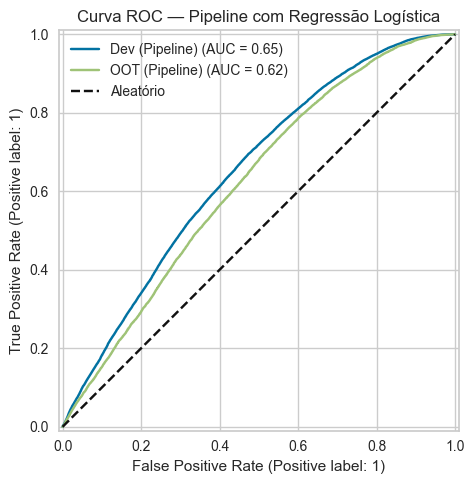

In [42]:
pipeline_final = Pipeline(steps=[
    ('preprocessamento', preprocessador),
    ('modelo', LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')),
])

pipeline_final.fit(X_dev, y_dev)
print("Pipeline completo treinado!\n")

prob_dev_pipe = pipeline_final.predict_proba(X_dev)[:, 1]
prob_oot_pipe = pipeline_final.predict_proba(X_oot)[:, 1]

avaliar("PIPELINE — BASE DE DESENVOLVIMENTO", y_dev.values, prob_dev_pipe)
avaliar("PIPELINE — BASE OUT OF TIME (OOT)", y_oot.values, prob_oot_pipe)

fig, ax = plt.subplots(figsize=(7, 5))
RocCurveDisplay.from_predictions(y_dev, prob_dev_pipe, ax=ax, name='Dev (Pipeline)')
RocCurveDisplay.from_predictions(y_oot, prob_oot_pipe, ax=ax, name='OOT (Pipeline)')
ax.plot([0, 1], [0, 1], 'k--', label='Aleatório')
ax.set_title('Curva ROC — Pipeline com Regressão Logística')
ax.legend()
plt.tight_layout()
plt.show()

### Salvar o pickle file do modelo treinado

In [43]:
import pickle

model = pipeline_final  # pipeline completo: pré-processamento + modelo

nome_arquivo = 'model_final.pkl'
with open(nome_arquivo, 'wb') as f:
    pickle.dump(model, f)

print(f"Modelo salvo em '{nome_arquivo}'")
print(f"Etapas: {[s[0] for s in model.steps]}")

# Verificar que carrega corretamente
with open(nome_arquivo, 'rb') as f:
    model_check = pickle.load(f)
prob_check = model_check.predict_proba(X_oot)[:, 1]
print(f"Pickle OK! Primeiras 5 probabilidades (OOT): {prob_check[:5].round(4)}")

Modelo salvo em 'model_final.pkl'
Etapas: ['preprocessamento', 'modelo']
Pickle OK! Primeiras 5 probabilidades (OOT): [0.4894 0.4121 0.4804 0.6658 0.5596]


# Pycaret na base de dados 

Utilize o pycaret para pre processar os dados e rodar o modelo **lightgbm**. Faça todos os passos a passos da aula e gere os gráficos finais. E o pipeline de toda a transformação.



In [44]:
from pycaret.classification import (ClassificationExperiment,
                                      setup, create_model, evaluate_model,
                                      predict_model, save_model, pull, models)

# Bases para o PyCaret (sem data_ref e index)
df_pycaret_dev = df_dev[features + ['mau']].copy()
df_pycaret_dev['mau'] = df_pycaret_dev['mau'].astype(int)
df_pycaret_dev['qtd_filhos'] = df_pycaret_dev['qtd_filhos'].astype(float)

df_pycaret_oot = df_oot[features + ['mau']].copy()
df_pycaret_oot['mau'] = df_pycaret_oot['mau'].astype(int)
df_pycaret_oot['qtd_filhos'] = df_pycaret_oot['qtd_filhos'].astype(float)

# Amostra de 50.000 para o PyCaret (performance)
df_sample = df_pycaret_dev.sample(50000, random_state=42).reset_index(drop=True)

# Setup PyCaret 3.x
exp = setup(
    data            = df_sample,
    target          = 'mau',
    session_id      = 42,
    fix_imbalance   = True,
    normalize       = True,
    pca             = True,
    pca_components  = 5,
    verbose         = False,
)
print('Setup PyCaret concluído!')
print(pull())

Setup PyCaret concluído!
                    Description             Value
0                    Session id                42
1                        Target               mau
2                   Target type            Binary
3           Original data shape       (50000, 13)
4        Transformed data shape        (80736, 6)
5   Transformed train set shape        (65736, 6)
6    Transformed test set shape        (15000, 6)
7              Numeric features                 5
8          Categorical features                 7
9      Rows with missing values             17.1%
10                   Preprocess              True
11              Imputation type            simple
12           Numeric imputation              mean
13       Categorical imputation              mode
14     Maximum one-hot encoding                25
15              Encoding method              None
16                Fix imbalance              True
17         Fix imbalance method             SMOTE
18                    Nor

In [45]:
# Modelos disponíveis no PyCaret
models()

,Name,Reference,Turbo
ID,,,
lr,Logistic Regression,sklearn.linear_model._logistic.LogisticRegression,True
knn,K Neighbors Classifier,sklearn.neighbors._classification.KNeighborsCl...,True
nb,Naive Bayes,sklearn.naive_bayes.GaussianNB,True
dt,Decision Tree Classifier,sklearn.tree._classes.DecisionTreeClassifier,True
svm,SVM - Linear Kernel,sklearn.linear_model._stochastic_gradient.SGDC...,True
rbfsvm,SVM - Radial Kernel,sklearn.svm._classes.SVC,False
gpc,Gaussian Process Classifier,sklearn.gaussian_process._gpc.GaussianProcessC...,False
mlp,MLP Classifier,sklearn.neural_network._multilayer_perceptron....,False
ridge,Ridge Classifier,sklearn.linear_model._ridge.RidgeClassifier,True


In [46]:
# df, df_dev e df_oot já estão definidos nas células anteriores — nenhuma ação necessária aqui.
print(f"df shape: {df.shape}")
print(f"df_dev shape: {df_dev.shape}")
print(f"df_oot shape:  {df_oot.shape}")

df shape: (750000, 15)
df_dev shape: (600000, 15)
df_oot shape:  (150000, 15)


In [47]:
# Criando o modelo LightGBM
lgbm = create_model('lightgbm', verbose=False)
print('Métricas de validação cruzada (LightGBM):')
print(pull())

Métricas de validação cruzada (LightGBM):
      Accuracy     AUC  Recall   Prec.      F1   Kappa     MCC
Fold                                                          
0       0.8129  0.5979  0.2160  0.0861  0.1232  0.0396  0.0449
1       0.8171  0.6364  0.3099  0.1181  0.1710  0.0909  0.1043
2       0.8123  0.6022  0.2019  0.0811  0.1157  0.0317  0.0358
3       0.8126  0.6363  0.2864  0.1080  0.1568  0.0751  0.0865
4       0.8203  0.6018  0.1643  0.0720  0.1001  0.0170  0.0187
5       0.8006  0.5774  0.2347  0.0855  0.1253  0.0396  0.0461
6       0.8189  0.6247  0.2488  0.1006  0.1432  0.0619  0.0699
7       0.8080  0.6369  0.2582  0.0967  0.1407  0.0572  0.0660
8       0.8217  0.6160  0.2056  0.0884  0.1236  0.0416  0.0463
9       0.8037  0.6039  0.1822  0.0708  0.1020  0.0152  0.0174
Mean    0.8128  0.6134  0.2308  0.0907  0.1302  0.0470  0.0536
Std     0.0067  0.0190  0.0435  0.0144  0.0216  0.0231  0.0266


In [48]:
# Importações já feitas na cell-46 — célula mantida apenas para compatibilidade
print("Pycaret já importado e setup concluído.")

Pycaret já importado e setup concluído.


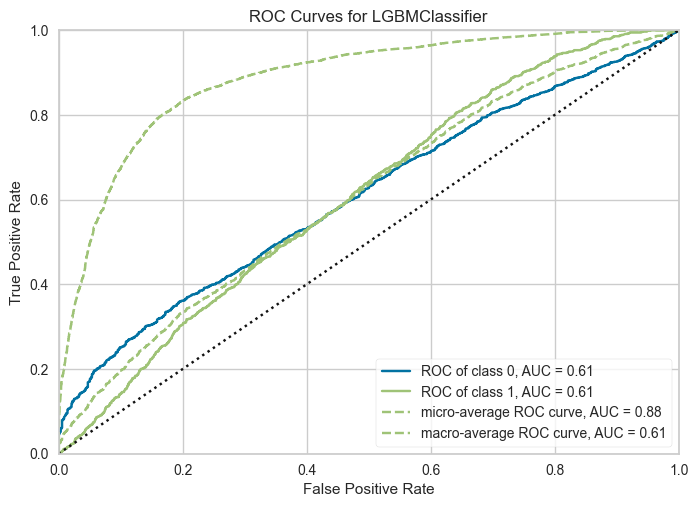

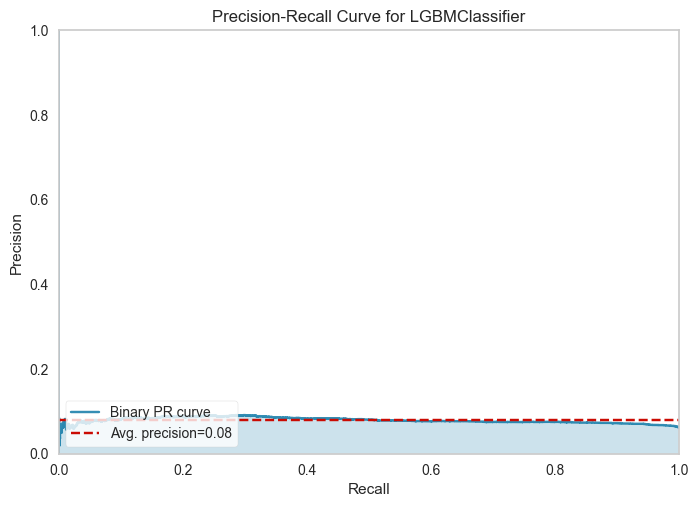

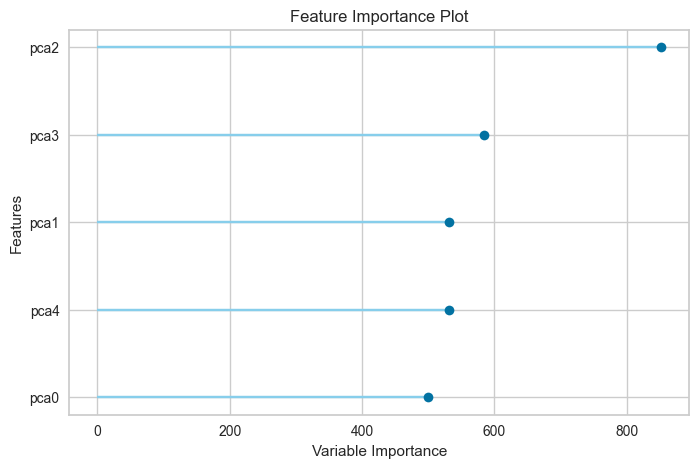

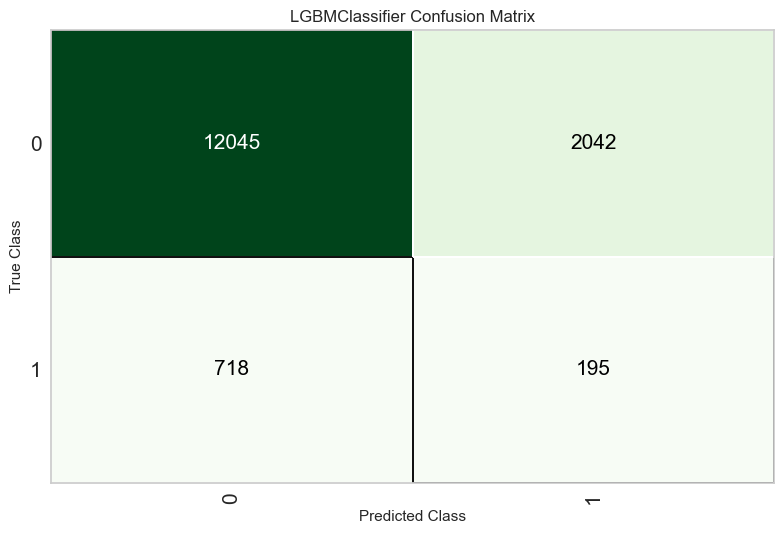

In [49]:
from pycaret.classification import plot_model

# Curva ROC
plot_model(lgbm, plot='auc', save=False)

# Precision-Recall
plot_model(lgbm, plot='pr', save=False)

# Importância das variáveis
plot_model(lgbm, plot='feature', save=False)

# Matriz de confusão
plot_model(lgbm, plot='confusion_matrix', save=False)

In [50]:
# Predição na base OOT (test_data)
predicoes_oot = predict_model(lgbm, data=df_pycaret_oot)
print('Métricas na base OOT:')
print(pull())
predicoes_oot.head()

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Light Gradient Boosting Machine,0.7491,0.5955,0.2262,0.1946,0.2092,0.0611,0.0614


Métricas na base OOT:
                             Model  Accuracy     AUC  Recall   Prec.      F1  \
0  Light Gradient Boosting Machine    0.7491  0.5955  0.2262  0.1946  0.2092   

    Kappa     MCC  
0  0.0611  0.0614  


,sexo,posse_de_veiculo,posse_de_imovel,qtd_filhos,tipo_renda,educacao,estado_civil,tipo_residencia,idade,tempo_emprego,qt_pessoas_residencia,renda,mau,prediction_label,prediction_score
600000,F,S,S,2.0,Assalariado,Superior completo,Casado,Casa,38,7.383562,4.0,2969.489990,1,0,0.8602
600001,F,N,S,0.0,Assalariado,Médio,Casado,Casa,55,8.471232,2.0,6278.370117,0,0,0.7657
600002,M,S,S,1.0,Assalariado,Médio,União,Casa,39,8.884932,3.0,14010.179688,0,0,0.8717
600003,F,N,S,1.0,Assalariado,Médio,União,Com os pais,31,1.794520,3.0,2875.810059,0,1,0.6521
600004,M,S,N,0.0,Assalariado,Médio,Casado,Casa,27,7.019178,2.0,2737.189941,0,0,0.8113


### Salvar o arquivo do modelo treinado

In [51]:
save_model(lgbm, 'model_pycaret_lgbm')
print("Modelo PyCaret salvo como 'model_pycaret_lgbm.pkl'")

Transformation Pipeline and Model Successfully Saved
Modelo PyCaret salvo como 'model_pycaret_lgbm.pkl'


# Projeto Final

1. Subir no GITHUB todos os jupyter notebooks/códigos que você desenvolveu nesse ultimo módulo
1. Gerar um arquivo python (.py) com todas as funções necessárias para rodar no streamlit a escoragem do arquivo de treino
    - Criar um .py
    - Criar um carregador de csv no streamlit 
    - Subir um csv no streamlit 
    - Criar um pipeline de pré processamento dos dados
    - Utilizar o modelo treinado para escorar a base 
        - nome_arquivo = 'model_final.pkl'
1. Gravar um vídeo da tela do streamlit em funcionamento (usando o próprio streamlit (temos aula disso) ou qlqr outra forma de gravação).
1. Subir no Github o vídeo de funcionamento da ferramenta como README.md.
1. Subir no Github os códigos desenvolvidos. 
1. Enviar links do github para o tutor corrigir.

In [53]:
streamlit_code = '''import streamlit as st
import pandas as pd
import pickle
import numpy as np
import matplotlib.pyplot as plt

st.set_page_config(page_title="Credit Scoring", page_icon="💳", layout="wide")
st.title("💳 Credit Scoring — Escoragem de Crédito")
st.markdown("Faça upload de um CSV e obtenha a probabilidade de inadimplência para cada cliente.")

@st.cache_resource
def carregar_modelo():
    with open("model_final.pkl", "rb") as f:
        return pickle.load(f)

model = carregar_modelo()

st.sidebar.header("📂 Carregar dados")
arquivo = st.sidebar.file_uploader("Selecione um arquivo CSV", type=["csv"])

if arquivo is not None:
    df = pd.read_csv(arquivo)
    st.subheader("Pré-visualização dos dados")
    st.dataframe(df.head(10))
    st.info(f"Total de registros: {len(df):,}")

    colunas_remover = [c for c in ["data_ref", "index", "mau"] if c in df.columns]
    X = df.drop(columns=colunas_remover)

    if st.sidebar.button("🚀 Escorar base"):
        with st.spinner("Calculando scores..."):
            try:
                probs = model.predict_proba(X)[:, 1]
                df_resultado = df.copy()
                df_resultado["score_mau"] = probs.round(4)
                df_resultado["classificacao"] = np.where(probs >= 0.5, "Mau", "Bom")

                st.subheader("✅ Resultado da escoragem")
                st.dataframe(df_resultado)

                col1, col2, col3 = st.columns(3)
                col1.metric("Total de clientes", f"{len(df_resultado):,}")
                col2.metric("% Previstos como Mau",
                            f"{(df_resultado['classificacao']=='Mau').mean():.1%}")
                col3.metric("Score médio", f"{probs.mean():.4f}")

                csv_resultado = df_resultado.to_csv(index=False).encode("utf-8")
                st.download_button("⬇️ Baixar resultado em CSV",
                                   data=csv_resultado,
                                   file_name="resultado_scoring.csv",
                                   mime="text/csv")

                fig, ax = plt.subplots(figsize=(8, 4))
                ax.hist(probs, bins=40, color="steelblue", edgecolor="white")
                ax.axvline(0.5, color="red", linestyle="--", label="Threshold 0.5")
                ax.set_xlabel("Probabilidade de Inadimplência")
                ax.set_ylabel("Frequência")
                ax.set_title("Distribuição dos Scores")
                ax.legend()
                st.pyplot(fig)

            except Exception as e:
                st.error(f"Erro ao escorar a base: {e}")
else:
    st.info("⬅️ Faça upload de um CSV na barra lateral para começar.")
    st.markdown("""
### Colunas esperadas no CSV:
| Coluna | Tipo |
|---|---|
| sexo | M / F |
| posse_de_veiculo | S / N |
| posse_de_imovel | S / N |
| qtd_filhos | int |
| tipo_renda | str |
| educacao | str |
| estado_civil | str |
| tipo_residencia | str |
| idade | int |
| tempo_emprego | float (pode ser nulo) |
| qt_pessoas_residencia | float |
| renda | float |
    """)
'''

with open('app.py', 'w', encoding='utf-8') as f:
    f.write(streamlit_code)

print("Arquivo 'app.py' gerado com sucesso!")
print("Para executar: streamlit run app.py")

Arquivo 'app.py' gerado com sucesso!
Para executar: streamlit run app.py
